In [372]:
# 1. Overview
# Customer churn, or customer attrition, refers to when a customer STOPS their relationship
# with a company or service provider. In today's highly competitive business environment,
# retaining customers is a critical factor for long-term success. Predicting customer churn can
# help organizations take proactive steps to retain customers, thus minimizing revenue loss.
# This project aims to build a machine learning model that can predict whether a customer will
# churn based on their demographic, account, and service-related data.

# 2. Problem Statement
# The goal of this project is to develop a classification model that predicts whether a customer
# will churn. Using demographic data (such as gender, senior citizen status, and tenure), along
# with information about the services they use (such as internet service, phone service, and
# online security), we will attempt to build a model that helps the company identify customers
# who are at a high risk of churning.
# By predicting customer churn, the company can proactively design retention strategies to
# keep these customers, thereby improving customer satisfaction and reducing financial loss.

# 3. Deliverables
# ● A data exploration and preprocessing notebook or report that analyzes the dataset,
# handles missing values, and prepares the data for modeling.
# ● A machine learning model capable of predicting customer churn.
# ● An evaluation of model performance using appropriate metrics (such as accuracy,
# precision, recall, F1 score, etc.).
# ● A final report explaining the insights gained from the model and the business
# implications of customer churn prediction.

# 4. Success Criteria
# The success of the project will be determined by the following:
# ● Proper interpretation of the model’s output, providing actionable insights to reduce
# customer churn.
# ● Get the predictions for the new data.

# 5. Guidelines
# ● Make sure to split your data into training and testing sets to avoid overfitting.
# ● Tune the hyperparameters of your models to improve performance.
# ● Report all the steps taken in the data preprocessing, modeling, and evaluation
# phases.
# ● Provide a final model that balances accuracy with interpretability.

In [373]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
df=pd.read_excel("CustomerChurnData.xlsx")
df.describe() # Summary Statistics

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [374]:
df.isnull().sum() # Check for Null Values

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [375]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


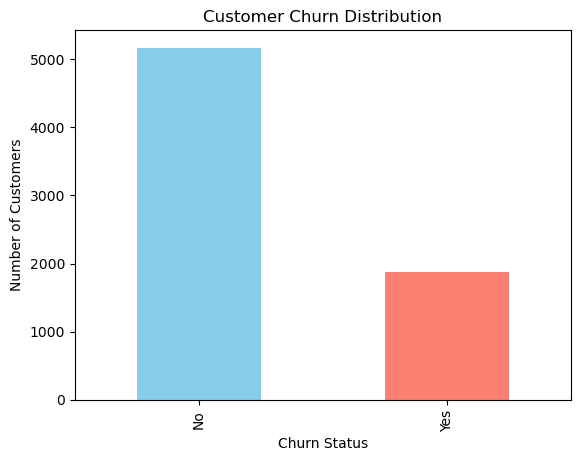

In [376]:
# 1. Load your data (assuming 'df' is your DataFrame)
# churn_counts will have counts for 'Yes' (churned) and 'No' (not churned)
churn_counts = df['Churn'].value_counts()

# 2. Create the bar plot
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

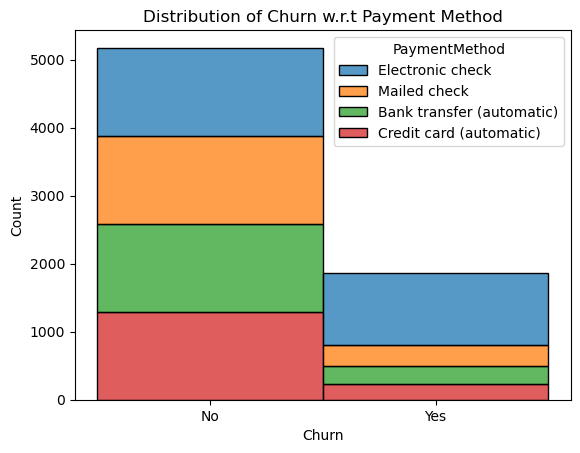

In [377]:
# Distribution of Churn w.r.t Payment Method
sns.histplot(data=df, x='Churn', hue='PaymentMethod', multiple='stack', bins=30) # Churn is on the X axis
plt.title('Distribution of Churn w.r.t Payment Method')
plt.show()

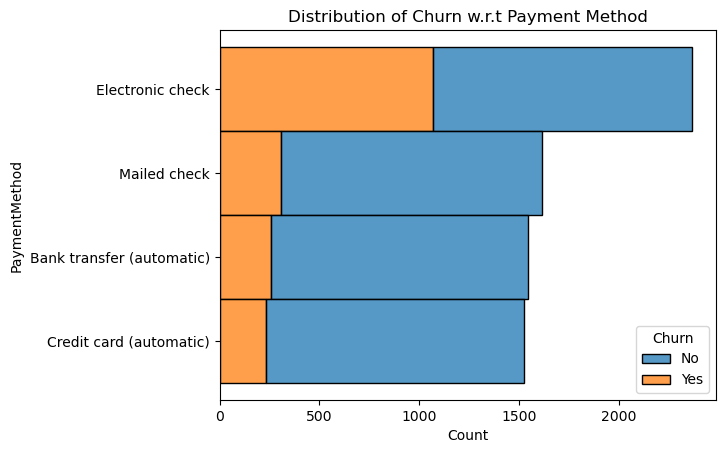

In [378]:
# Proportion of Churn in different Payment Methods
sns.histplot(data=df, y='PaymentMethod', hue='Churn', multiple='stack', bins=10) # Payment is on the Y axis
plt.title('Distribution of Churn w.r.t Payment Method')
plt.show()

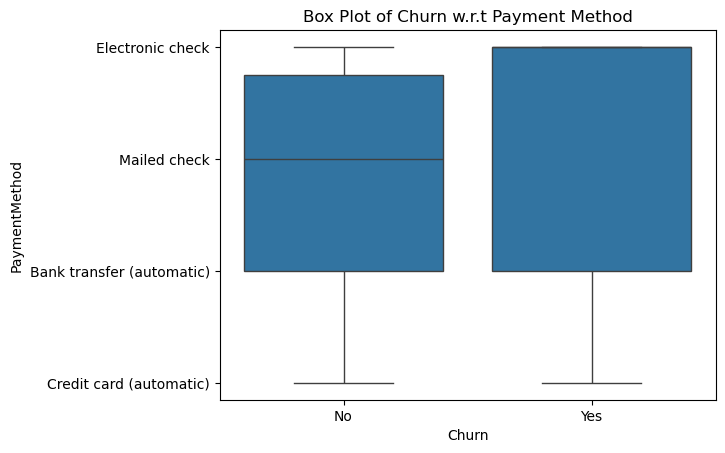

In [379]:
# Box Plot for Payment Method w.r.t Payment Method
sns.boxplot(x='Churn', y='PaymentMethod', data=df)
plt.title('Box Plot of Churn w.r.t Payment Method')
plt.show()

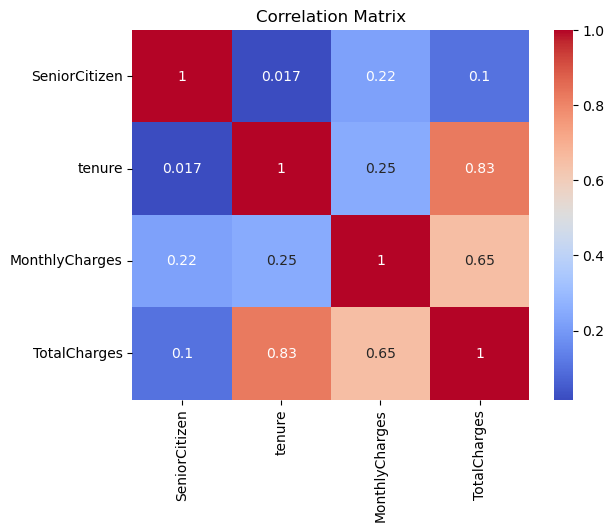

In [380]:
# Correlation Matrix (It is a Symmetric Matrix)
num_cols=list()
for column in df.columns:
    if df[column].dtype!=object:
        num_cols.append(column)
correlation_matrix=df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()    
# Correlation Matrix takes into account only the Numerical columns. 
# Correlation requires calculating mathematical means and variances.

# Data Cleaning

In [381]:
# Split the data into training and testing datasets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42)

# Data Cleaning (of Training Data)
# 1. Convert to DataFrame to use dropna()
X_train_df = pd.DataFrame(X_train)
# 2. Drop NaNs and save the remaining row indices
X_train_clean = X_train_df.dropna()
# 3. Use those same indices to clean y_train
y_train_clean = y_train[X_train_clean.index]

# Data Cleaning (of Testing Data)
# 1. Convert to DataFrame to use dropna()
X_test_df = pd.DataFrame(X_test)
# 2. Drop NaNs and save the remaining row indices
X_test_clean = X_test_df.dropna()
# 3. Use those same indices to clean y_train
y_test_clean = y_test[X_test_clean.index]

# Data Preprocessing

In [382]:
# Encode Categorical Variables (Give Numerical Values to entries in Category Column)
label_encoders={}
for column in {'customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
               'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'}:
    le = LabelEncoder() # Initialize the encoder
    df[column] = le.fit_transform(df[column]) # Fit and transform your data
    label_encoders[column]=le
    # print(le.classes_)   # View the mapping (e.g., ['No', 'Yes'])
# Features and Target 
X=df.drop(['Churn', 'customerID'], axis=1) # axis=1 means operation by column
                                           # axis=0 means operation by row
y=df['Churn']

# Feature Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_clean)
X_test_scaled=scaler.transform(X_test_clean)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(X_train_scaled, y_train_clean) # Now fit your model
logreg_pred=logreg.predict(X_test_scaled)
logreg_accuracy=accuracy_score(y_test_clean, logreg_pred)
# Display Accuracy and performance metrics
print(f"Logistic Regression Accuracy:{logreg_accuracy*100:.2f}")
print('\n Logistic Regression Classification Report: ' )
print(classification_report(y_test_clean, logreg_pred))

Logistic Regression Accuracy:81.00

 Logistic Regression Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1536
           1       0.68      0.57      0.62       574

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.80      0.81      0.80      2110

